# One model per category, or one model for all of them?

The shipped scenario tool fits **one** response model across all five categories.
Every category shares the same price elasticity, the same media elasticity, the
same everything -- only the overall level is allowed to differ. That is a strong
assumption, and this notebook tests it by building the alternative and scoring
both.

**How to read this notebook.** It imports nothing from `src/` or `config.py`.
Every function the model needs is written out below in plain numpy and pandas, so
you never have to open another file to see what a step does. Each code cell is
preceded by a plain-English description of what it does and why.

The path we'll walk:

| Section | What happens |
|---|---|
| 0 | Setup: the driver spec and the data |
| 1 | Turning raw drivers into numbers a regression can use |
| 2 | The solver, and why it needs sign constraints |
| 3 | Fitting the pooled model (arm A) — the baseline |
| 4 | Fitting one model per category (arm B) — the thing you asked for |
| 5 | The confound: is arm B actually winning on *drivers*? (arm C) |
| 6 | The middle ground: partial pooling (arms D, E) |
| 7 | The verdict, and what it means for the sliders |

**The short answer**, so you know where this is going: splitting the model cuts
forecast error by two-thirds — but almost all of that gain comes from letting each
category have its own *seasonality and trend*, not from letting it have its own
*driver elasticities*. And on the elasticities themselves — the numbers the
sliders actually use — fully splitting makes things **worse**. The best arm is a
compromise between the two.

---
# 0. Setup

## 0.1 The only imports

Four outside packages, and that's it:

- **numpy** — array maths
- **pandas** — tables (the panel of monthly data)
- **matplotlib** — charts
- **`lsq_linear` from scipy** — a least-squares solver that can enforce limits on
  the answer. Section 2 explains why we need one that does that.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import lsq_linear

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# Chart styling: muted grid, dark-ish text, a fixed set of series colours.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
BLUE, ORANGE, AQUA, YELLOW = SERIES[0], SERIES[1], SERIES[2], SERIES[3]
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "text.color": "#52514e", "font.size": 10, "figure.dpi": 110,
})
print("ready")

ready


## 0.2 The driver spec

This dictionary is the heart of the whole model. For each of the nine drivers it
records four things:

- **`transform`** — how to compress the driver before regressing. `"log"` for
  things that are always positive (price, distribution). `"log1p"` (which means
  `log(1 + x)`) for things that can legitimately be **zero** — media spend goes to
  zero in dark months, and `log(0)` is negative infinity, which would blow up.
- **`sign`** — the direction we *know* the driver must push volume. `-1` means
  raising it must lower volume (price), `+1` means raising it must raise volume
  (distribution), `0` means we genuinely don't know. Section 2.3 shows why this
  matters enormously.
- **`adstock`** — only media has this. It means spend carries over into later
  months instead of vanishing. Section 1.1 explains.
- **`group`** — `"Commercial"` drivers are things the business controls and that
  differ per category. `"Macro"` drivers are the outside world: one shared
  national series that every category sees identically. **This distinction turns
  out to decide the whole experiment.**

In [2]:
DRIVERS = {
    "avg_price":           {"transform": "log",   "sign": -1, "group": "Commercial",
                            "label": "Average price ($/unit)"},
    "distribution_acv":    {"transform": "log",   "sign":  1, "group": "Commercial",
                            "label": "Distribution (% ACV)"},
    "promo_depth":         {"transform": "log1p", "sign":  1, "group": "Commercial",
                            "label": "Promo depth (avg % off)"},
    "promo_share":         {"transform": "log1p", "sign":  1, "group": "Commercial",
                            "label": "Weeks on promo (% of weeks)"},
    "media_spend":         {"transform": "log1p", "sign":  1, "group": "Commercial",
                            "label": "Media spend ($k)", "adstock": 0.45},
    "cpi_food":            {"transform": "log",   "sign": -1, "group": "Macro",
                            "label": "Food CPI index"},
    "consumer_confidence": {"transform": "log",   "sign":  1, "group": "Macro",
                            "label": "Consumer confidence"},
    "unemployment_rate":   {"transform": "log",   "sign": -1, "group": "Macro",
                            "label": "Unemployment rate (%)"},
    "avg_temp_c":          {"transform": "log",   "sign":  0, "group": "Macro",
                            "label": "Average temperature (C)"},
}

DRIVER_NAMES = list(DRIVERS)
COMMERCIAL = [d for d, s in DRIVERS.items() if s["group"] == "Commercial"]
MACRO      = [d for d, s in DRIVERS.items() if s["group"] == "Macro"]

CATEGORIES = ["Beverages", "Snacks", "Dairy", "Frozen Foods", "Household Care"]

HOLDOUT_MONTHS = 12          # last 12 months are hidden from every fit and used to score
CV_SPLITS      = 4           # folds used to choose the ridge penalty
RIDGE_ALPHAS   = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 3.0, 10.0, 30.0, 100.0]

print(f"{len(DRIVER_NAMES)} drivers  ({len(COMMERCIAL)} commercial, {len(MACRO)} macro)")
print(f"{len(CATEGORIES)} categories")

9 drivers  (5 commercial, 4 macro)
5 categories


## 0.3 Load the panel

`data/panel.csv` is a **panel**: every row is one category in one month, with the
volume sold and the nine driver values for that month. 5 categories x 66 months =
330 rows.

We sort by category then date and reset the row numbers. That ordering matters
later — the adstock calculation in the next section walks down the rows in time
order within each category, so the rows have to actually be in that order.

In [3]:
panel = (pd.read_csv("../data/panel.csv", parse_dates=["date"])
           .sort_values(["category", "date"])
           .reset_index(drop=True))

T0 = panel["date"].min()          # the clock starts here; used by the trend term

print(f"{panel.shape[0]} rows x {panel.shape[1]} columns, "
      f"{panel['date'].min():%Y-%m} -> {panel['date'].max():%Y-%m}")
panel.head(3)

330 rows x 12 columns, 2021-01 -> 2026-06


,date,category,volume,avg_price,distribution_acv,promo_depth,promo_share,media_spend,cpi_food,consumer_confidence,unemployment_rate,avg_temp_c
0,2021-01-01,Beverages,1036652.0,2.989800,71.938136,17.447734,29.958208,120.250252,100.262447,98.597897,6.799616,3.041770
1,2021-02-01,Beverages,1618220.0,2.921831,72.770464,19.129773,31.741227,131.216345,99.925698,97.214313,6.074504,4.810926
2,2021-03-01,Beverages,1451689.0,2.979812,72.502025,15.652733,31.554195,97.952941,100.363458,96.741762,6.046535,7.674098


## 0.4 The ground truth

The panel is **synthetic** — it was generated from known elasticities, then had
noise added. That is a gift: we can score every model against the right answer
instead of guessing.

The table below is what the generator actually used. Note two things:

1. Each category's elasticities are jittered around a global value, so **no single
   pooled number is right for everyone.**
2. A few were set by hand to be genuinely different, and those are the interesting
   cases:
   - **Dairy price is −1.15** vs about −1.7 everywhere else. It's a staple; people
     buy milk whatever it costs.
   - **Temperature ranges from +0.42 (Beverages) to −0.02 (Household Care).** Heat
     sells drinks. Heat does nothing for dish soap.

If per-category modelling is ever going to pay off, it should pay off *here*.

In [4]:
# Copied from data_gen.true_category_elasticity_table() so this notebook stays
# self-contained. Regenerate with:
#     python -c "from src import data_gen; print(data_gen.true_category_elasticity_table())"
TRUTH = pd.DataFrame(
    [[-1.6879, 0.9549, 0.6113, 0.3028, 0.0794, -0.5632, 0.4411, -0.1687,  0.4200],
     [-1.7926, 0.8613, 0.5888, 0.2984, 0.0738, -0.6033, 0.4659, -0.2040,  0.1002],
     [-1.1500, 0.9612, 0.5716, 0.3284, 0.0611, -0.6120, 0.4138, -0.2013,  0.1069],
     [-1.7421, 0.9221, 0.6107, 0.2856, 0.0659, -0.6579, 0.5169, -0.1630,  0.2400],
     [-1.6179, 0.8996, 0.5263, 0.2559, 0.0621, -0.6375, 0.3922, -0.1621, -0.0200]],
    index=CATEGORIES, columns=DRIVER_NAMES,
)

print("True elasticities per category (% volume change per 1% driver change):")
display(TRUTH.round(3))
print("\nSpread across categories (max - min) -- where splitting could help:")
print((TRUTH.max() - TRUTH.min()).sort_values(ascending=False).round(3).to_string())

True elasticities per category (% volume change per 1% driver change):


,avg_price,distribution_acv,promo_depth,promo_share,media_spend,cpi_food,consumer_confidence,unemployment_rate,avg_temp_c
Beverages,-1.688,0.955,0.611,0.303,0.079,-0.563,0.441,-0.169,0.420
Snacks,-1.793,0.861,0.589,0.298,0.074,-0.603,0.466,-0.204,0.100
Dairy,-1.150,0.961,0.572,0.328,0.061,-0.612,0.414,-0.201,0.107
Frozen Foods,-1.742,0.922,0.611,0.286,0.066,-0.658,0.517,-0.163,0.240
Household Care,-1.618,0.900,0.526,0.256,0.062,-0.638,0.392,-0.162,-0.020



Spread across categories (max - min) -- where splitting could help:
avg_price              0.643
avg_temp_c             0.440
consumer_confidence    0.125
distribution_acv       0.100
cpi_food               0.095
promo_depth            0.085
promo_share            0.073
unemployment_rate      0.042
media_spend            0.018


---
# 1. Turning raw drivers into regression inputs

Three transformations happen before any model sees the data. This section builds
each one and shows what it does.

## 1.1 Adstock — media spend doesn't vanish at month end

If you run a campaign in June, some of that effect is still working in July. So
before modelling, media spend is replaced by a running total that decays:

    carried[t] = spend[t] + 0.45 * carried[t-1]

45% of last month's carried effect survives into this month. The function below
walks down the months once, keeping that running total.

Only media has this. Price doesn't carry over — last month's price is simply not
this month's price.

In [5]:
def adstock(x, decay):
    """Running total that decays: each month keeps `decay` of what came before."""
    out = np.empty(len(x))
    carry = 0.0
    for i, value in enumerate(x):
        carry = value + decay * carry
        out[i] = carry
    return out


# Show it on real numbers: a burst month followed by nothing.
demo = np.array([0.0, 0.0, 100.0, 0.0, 0.0, 0.0])
print("raw spend    :", demo)
print("after adstock:", adstock(demo, 0.45).round(1))
print("\nThe 100 spent in month 2 is still contributing 45, then 20, then 9.")

raw spend    : [  0.   0. 100.   0.   0.   0.]
after adstock: [  0.    0.  100.   45.   20.2   9.1]

The 100 spent in month 2 is still contributing 45, then 20, then 9.


Here it is on the real Beverages media plan. The orange line is what the model
actually sees — smoother than the raw plan, and shifted slightly later, which is
what carryover looks like.

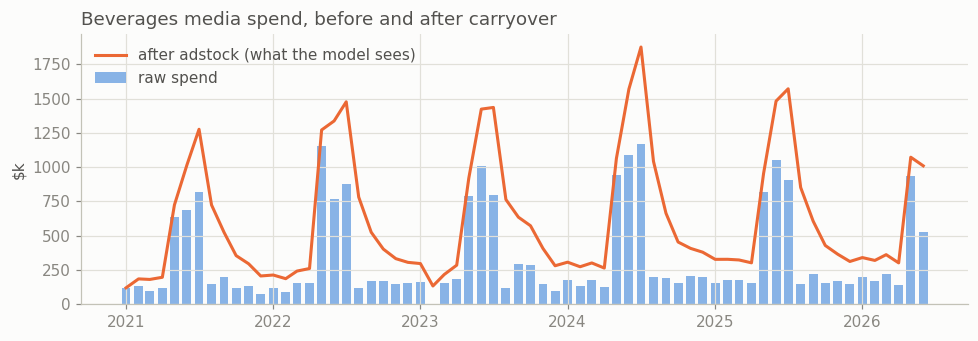

In [6]:
bev = panel[panel["category"] == "Beverages"]

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(bev["date"], bev["media_spend"], width=22, color=BLUE, alpha=0.55,
       label="raw spend")
ax.plot(bev["date"], adstock(bev["media_spend"].to_numpy(), 0.45),
        color=ORANGE, lw=2, label="after adstock (what the model sees)")
ax.set_title("Beverages media spend, before and after carryover", loc="left")
ax.set_ylabel("$k")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 1.2 The log transform — why every column gets logged

We model `log(volume)` against `log(driver)`. That sounds like a technicality but
it buys something specific: **the coefficients become elasticities.**

An elasticity is "% change in volume per 1% change in the driver". So a price
coefficient of −1.7 reads directly as *"cut price 1%, sell 1.7% more"*. No
conversion, no units. That is exactly the number a scenario slider needs.

The alternative — modelling raw volume against raw price — would give you "units
per dollar", which changes meaning for every category and can't be compared.

Two flavours, as set in the driver spec:
- `log(x)` for drivers that are always positive.
- `log(1 + x)` for drivers that can be zero (media). `log(0)` is minus infinity;
  `log(1 + 0)` is a well-behaved 0.

In [7]:
def log_transform(df):
    """Each driver column -> its log version, named `l_<driver>`."""
    out = pd.DataFrame(index=df.index)
    for name, spec in DRIVERS.items():
        x = df[name].to_numpy(float)
        if spec["transform"] == "log":
            out[f"l_{name}"] = np.log(np.clip(x, 1e-6, None))   # clip guards log(0)
        else:                                                    # log1p
            out[f"l_{name}"] = np.log1p(np.clip(x, 0.0, None))
    return out


LOG_COLS = [f"l_{n}" for n in DRIVER_NAMES]
print(log_transform(panel.head(3))[["l_avg_price", "l_media_spend"]].round(3).to_string())

   l_avg_price  l_media_spend
0        1.095          4.798
1        1.072          4.884
2        1.092          4.595


## 1.3 The design matrix

The **design matrix** is the table of numbers fed to the regression: one row per
observation, one column per thing the model is allowed to use. Ours has four kinds
of column:

| Columns | How many | What they capture |
|---|---|---|
| `l_<driver>` | 9 | the logged drivers — these give the elasticities |
| `trend` | 1 | months since the start, in years — organic growth |
| `cat_<name>` | 4 | category dummies — the *level* difference between categories |
| `mon_2` … `mon_12` | 11 | month dummies — seasonality |

**On dummies**: a dummy is a 0/1 column meaning "is this row that category?". With
five categories we only need four columns — if all four are 0, it must be the
fifth. Including all five would make them perfectly redundant. Same for months:
eleven columns, January is the leftover.

**The important bit for this notebook**: `cat_*` columns shift each category's
level up or down, but there is only **one** `trend` column and **one** set of month
dummies, shared by everyone. So the pooled model assumes all five categories grow
at the same rate and have the same seasonal shape. Hold that thought — section 5
is about exactly this.

In [8]:
def build_design(df):
    """Raw panel -> the table of numbers the regression consumes."""
    df = df.sort_values(["category", "date"]).copy()

    # 1. Apply adstock, per category, in date order.
    for name, spec in DRIVERS.items():
        if "adstock" in spec:
            df[name] = df.groupby("category")[name].transform(
                lambda s: adstock(s.to_numpy(), spec["adstock"]))

    # 2. Log everything.
    X = log_transform(df)

    # 3. Trend: months since T0, expressed in years.
    months_elapsed = (df["date"].dt.year - T0.year) * 12 + (df["date"].dt.month - T0.month)
    X["trend"] = months_elapsed.to_numpy(float) / 12.0

    # 4. Category dummies (first category is the reference, so it gets no column).
    for c in CATEGORIES[1:]:
        X[f"cat_{c}"] = (df["category"] == c).astype(float).to_numpy()

    # 5. Month dummies (January is the reference).
    for m in range(2, 13):
        X[f"mon_{m}"] = (df["date"].dt.month == m).astype(float).to_numpy()

    return X


NUM_COLS = LOG_COLS + ["trend"]                       # continuous columns
CAT_COLS = [f"cat_{c}" for c in CATEGORIES[1:]]       # category dummies
MON_COLS = [f"mon_{m}" for m in range(2, 13)]         # month dummies

X = build_design(panel)
y = np.log(panel["volume"].to_numpy())                # the target: log volume

print(f"design matrix: {X.shape[0]} rows x {X.shape[1]} columns")
print(f"  {len(NUM_COLS)} continuous  +  {len(CAT_COLS)} category  +  {len(MON_COLS)} month")
X[["l_avg_price", "trend", "cat_Snacks", "mon_7"]].head(3).round(3)

design matrix: 330 rows x 25 columns
  10 continuous  +  4 category  +  11 month


,l_avg_price,trend,cat_Snacks,mon_7
0,1.095,0.000,0.0,0.0
1,1.072,0.083,0.0,0.0
2,1.092,0.167,0.0,0.0


---
# 2. The solver

## 2.1 Why plain regression fails here

The drivers are badly tangled up with each other. Average price is *defined* net
of promotion, so price, promo depth and promo share move together mechanically.
Worse, food CPI drifts upward over the whole period — and so does the trend column.

The correlation table below shows the damage. When two columns are nearly
identical, a regression cannot tell which one deserves the credit. It will happily
put a huge positive number on one and a huge negative number on the other; they
cancel out and the fit looks fine, but both coefficients are nonsense.

In [9]:
corr = X[LOG_COLS + ["trend"]].corr()
pairs = (corr.where(~np.eye(len(corr), dtype=bool))
             .stack().sort_values(key=abs, ascending=False))
print("Most entangled pairs:")
print(pairs.drop_duplicates().head(6).round(3).to_string())

Most entangled pairs:
trend                l_cpi_food               0.963
l_promo_share        l_promo_depth            0.889
l_unemployment_rate  l_cpi_food              -0.730
trend                l_consumer_confidence    0.629
l_unemployment_rate  trend                   -0.628
l_cpi_food           l_distribution_acv       0.597


`l_cpi_food` and `trend` are correlated about **0.96**. They are, for practical
purposes, the same column. Let's see what an unconstrained fit does with that.

In [10]:
def plain_least_squares(design, target, cols):
    """Ordinary regression with no penalty and no constraints."""
    A = np.column_stack([np.ones(len(design)), design[cols].to_numpy(float)])
    coef, *_ = np.linalg.lstsq(A, target, rcond=None)
    return pd.Series(coef[1:], index=cols)

naive = plain_least_squares(X, y, NUM_COLS + CAT_COLS + MON_COLS)
print("Unconstrained fit, the two entangled columns:")
print(f"  l_cpi_food elasticity : {naive['l_cpi_food']:+.3f}   (truth is about -0.62)")
print(f"  trend                 : {naive['trend']:+.3f}")

Unconstrained fit, the two entangled columns:
  l_cpi_food elasticity : +0.413   (truth is about -0.62)
  trend                 : +0.007


**There it is.** The unconstrained fit says food inflation *increases* volume.
It doesn't believe that; it just can't separate CPI from the trend, so it put a
large positive number on one and absorbed the offset in the other.

If that coefficient shipped, the scenario tool would tell a planner "food
inflation is good for you". That is worse than useless.

## 2.2 Two fixes, applied together

**Fix 1 — ridge (shrinkage).** Add a penalty for large coefficients. When two
columns are interchangeable, the penalty prefers splitting the effect between them
over the huge-positive/huge-negative cancellation. The strength of the penalty is
called **alpha**: alpha=0 is plain regression, large alpha squashes everything
toward zero.

**Fix 2 — sign constraints.** For most drivers we *know* the direction from
business sense. Price cannot increase volume. Distribution cannot decrease it. So
we forbid the wrong sign outright. That's the `sign` field in the driver spec.

## 2.3 How ridge is actually computed

There's a neat trick here worth understanding, because it's why one solver can do
both fixes at once.

Ridge means: find coefficients that minimise
`(prediction error)² + alpha × (size of coefficients)²`.

That second term can be smuggled into the first by **adding fake rows** to the
data. Stack `sqrt(alpha) × identity` underneath the design matrix, and stack
zeros underneath the target. Each fake row says "this one coefficient should be
zero", weighted by `sqrt(alpha)`. Solving ordinary least squares on the enlarged
system gives exactly the ridge answer.

Why bother? Because now it is an ordinary least-squares problem — and `lsq_linear`
solves ordinary least squares **with limits on each coefficient**. So the fake
rows give us shrinkage and the limits give us sign constraints, in one call.

One detail: we subtract the mean from every column and from the target first. That
makes the intercept fall out separately, so it never gets penalised or
constrained — you don't want to shrink "the average size of the category".

In [11]:
def solve_ridge(Z, target, alpha, lower, upper):
    """Ridge regression with a floor and ceiling on each coefficient.

    Z       : design matrix (already scaled)
    alpha   : penalty strength; 0 = no shrinkage
    lower/upper : per-coefficient limits. Use -inf / +inf for 'no limit'.
    """
    n_cols = Z.shape[1]

    # Centre both sides so the intercept is handled separately (and never penalised).
    col_means, target_mean = Z.mean(axis=0), target.mean()
    Z_centred = Z - col_means
    target_centred = target - target_mean

    # The trick: fake rows that penalise coefficient size.
    A = np.vstack([Z_centred, np.sqrt(alpha) * np.eye(n_cols)])
    b = np.concatenate([target_centred, np.zeros(n_cols)])

    coef = lsq_linear(A, b, bounds=(lower, upper), method="bvls", max_iter=500).x
    intercept = float(target_mean - col_means @ coef)
    return coef, intercept


print("solve_ridge defined")

solve_ridge defined


## 2.4 Scaling, and reading the answer back

One more wrinkle. The penalty punishes *large coefficients*, but "large" depends
on the units of the column. A column that varies between 4.0 and 4.2 needs a big
coefficient to matter; a column that varies between 0 and 100 needs a small one.
Penalising them equally would be arbitrary.

The fix is to divide each continuous column by its standard deviation first, so
they're all on a comparable footing. Then, to read the answer back as a real
elasticity, we divide the fitted coefficient by that same standard deviation.

The dummy columns are left alone — they're already 0/1, so there's nothing to
normalise.

`fit_model` below does all of it and hands back a small dictionary. The important
key is **`beta`** — the elasticities in real units, which is what everything after
this point actually uses.

In [12]:
def fit_model(design, target, num_cols, dummy_cols, alpha, free_signs=False):
    """Fit one sign-constrained ridge model. Returns a dict describing the fit.

    num_cols    : continuous columns (logged drivers, trend)
    dummy_cols  : 0/1 columns (category and/or month)
    free_signs  : if True, skip the sign constraints entirely
    """
    cols = num_cols + dummy_cols
    Z = design[cols].to_numpy(float).copy()
    k = len(num_cols)

    # Scale the continuous columns only.
    scale = Z[:, :k].std(axis=0)
    scale[scale == 0] = 1.0
    Z[:, :k] /= scale

    # Build the per-coefficient limits from the driver spec.
    lower = np.full(len(cols), -np.inf)
    upper = np.full(len(cols),  np.inf)
    if not free_signs:
        for i, col in enumerate(num_cols):
            sign = DRIVERS[col[2:]]["sign"] if col.startswith("l_") else 0
            if sign > 0:
                lower[i] = 0.0        # must be positive
            elif sign < 0:
                upper[i] = 0.0        # must be negative

    coef, intercept = solve_ridge(Z, target, alpha, lower, upper)

    return {
        "coef": coef, "intercept": intercept, "scale": scale,
        "num_cols": num_cols, "dummy_cols": dummy_cols, "alpha": alpha,
        # Elasticities in real units: undo the scaling.
        "beta": pd.Series(coef[:k] / scale, index=num_cols),
    }


def predict_log(fit, design):
    """Predicted log volume for the rows of `design`."""
    Z = design[fit["num_cols"] + fit["dummy_cols"]].to_numpy(float).copy()
    Z[:, :len(fit["num_cols"])] /= fit["scale"]
    return Z @ fit["coef"] + fit["intercept"]


print("fit_model and predict_log defined")

fit_model and predict_log defined


### Does the constraint actually do anything?

Worth checking rather than assuming. Fit the same data at several penalty
strengths, with the constraints on and off, and watch the CPI coefficient.

In [13]:
rows = []
for a in [0.0, 0.001, 0.01, 0.05, 0.5]:
    off = fit_model(X, y, NUM_COLS, CAT_COLS + MON_COLS, a, free_signs=True)
    on  = fit_model(X, y, NUM_COLS, CAT_COLS + MON_COLS, a)
    rows.append({"alpha": a,
                 "CPI unconstrained": off["beta"]["l_cpi_food"],
                 "CPI constrained":   on["beta"]["l_cpi_food"],
                 "constraint binds?": off["beta"]["l_cpi_food"] > 0})
print(pd.DataFrame(rows).set_index("alpha").round(3).to_string())

       CPI unconstrained  CPI constrained  constraint binds?
alpha                                                       
0.000              0.413            0.000               True
0.001              0.374            0.000               True
0.010              0.086            0.000               True
0.050             -0.520           -0.520              False
0.500             -1.141           -1.141              False


This is more nuanced than "the constraint saves us", and worth being precise about.

**Shrinkage and the constraint are overlapping defences.** With little or no
penalty the unconstrained fit puts CPI at **+0.41** — the wrong sign — and the
constraint is doing all the work, pinning it to the boundary at zero. But by
alpha = 0.05, which is what cross-validation actually picks, ridge alone has
already pulled CPI to −0.52 and the constraint no longer binds at all.

So on *this* dataset the constraint is a guardrail rather than the active
ingredient. That is not an argument for dropping it: it costs nothing when it
doesn't bind, and it's the only thing standing between a weaker penalty and a
scenario tool that recommends inflation as a growth strategy.

---
# 3. Arm A: the pooled model (the baseline)

## 3.1 Choosing alpha honestly

Alpha controls how hard we shrink. Too little and the entangled drivers misbehave;
too much and everything is squashed toward zero. We pick it by cross-validation:
try each candidate, see which forecasts best on data it wasn't fitted to.

But this is time-series data, so the folds cannot be random. Predicting January
from December is cheating — in reality you only ever have the past. So we use
**expanding windows**: fit on everything up to a date, test on the next slice,
then move the line forward.

Note the folds are cut on **dates**, not row numbers. All five categories share the
same calendar, so a cut has to take all five at once.

In [14]:
def time_folds(dates, n_splits=CV_SPLITS):
    """Expanding-window splits: always train on the past, test on the future."""
    unique_dates = np.sort(dates.unique())
    edges = np.linspace(len(unique_dates) // 2, len(unique_dates), n_splits + 1).astype(int)
    d = dates.to_numpy()
    for i in range(n_splits):
        train_end = unique_dates[edges[i] - 1]
        test_end  = unique_dates[edges[i + 1] - 1]
        train = np.where(d <= train_end)[0]
        test  = np.where((d > train_end) & (d <= test_end))[0]
        if len(train) and len(test):
            yield train, test


for i, (tr, te) in enumerate(time_folds(panel["date"]), 1):
    print(f"fold {i}: train on {len(tr):3d} rows -> test on {len(te):3d} rows "
          f"({panel.loc[te, 'date'].min():%Y-%m} to {panel.loc[te, 'date'].max():%Y-%m})")

fold 1: train on 165 rows -> test on  40 rows (2023-10 to 2024-05)
fold 2: train on 205 rows -> test on  40 rows (2024-06 to 2025-01)
fold 3: train on 245 rows -> test on  40 rows (2025-02 to 2025-09)
fold 4: train on 285 rows -> test on  45 rows (2025-10 to 2026-06)


Now the alpha search: for each candidate, run every fold, average the squared
error, keep the winner.

In [15]:
def pick_alpha(design, target, dates, num_cols, dummy_cols, **kwargs):
    """Try each alpha across the time folds; return the one with lowest error."""
    folds = list(time_folds(dates))
    scores = {}
    for alpha in RIDGE_ALPHAS:
        errors = []
        for train, test in folds:
            f = fit_model(design.iloc[train], target[train], num_cols, dummy_cols,
                          alpha, **kwargs)
            errors.append(np.mean((target[test] - predict_log(f, design.iloc[test])) ** 2))
        scores[alpha] = np.mean(errors)
    return min(scores, key=scores.get), pd.Series(scores)


best_alpha, alpha_scores = pick_alpha(X, y, panel["date"], NUM_COLS, CAT_COLS + MON_COLS)
print(f"chosen alpha = {best_alpha}\n")
print("cross-validated error by alpha:")
print(alpha_scores.round(5).to_string())

chosen alpha = 0.05

cross-validated error by alpha:
0.001      0.02874
0.010      0.02809
0.050      0.02802
0.100      0.02813
0.500      0.02869
1.000      0.02942
3.000      0.03147
10.000     0.03481
30.000     0.04090
100.000    0.05987


## 3.2 The holdout

Cross-validation picked alpha. To score the *model*, we need data that played no
part in fitting at all — so the last 12 months are held out entirely.

**One subtlety that is easy to get wrong**, and worth understanding because it
caused a real bug in this repo: the design matrix is built **once over the whole
panel**, then sliced. If you rebuilt it using only the holdout rows, the media
adstock carry would restart from zero at the boundary — the model would be told
that no media ran before the holdout, understating carryover in exactly the months
you're trying to score. Build once, slice after.

In [16]:
cutoff  = panel["date"].max() - pd.DateOffset(months=HOLDOUT_MONTHS)
is_test = (panel["date"] > cutoff).to_numpy()
is_train = ~is_test

print(f"train: {is_train.sum()} rows up to {cutoff:%Y-%m}")
print(f"test : {is_test.sum()} rows after")


def mape(predicted_log, actual_log):
    """Mean absolute percentage error, computed on volumes not logs."""
    return float(np.mean(np.abs(np.exp(predicted_log) / np.exp(actual_log) - 1)) * 100)


def holdout_score(fit_fn):
    """Fit on the training rows only, then score on the hidden 12 months.

    `fit_fn(train_mask)` must return a function mapping a row mask -> predicted logs.
    """
    predict = fit_fn(is_train)
    pred = predict(is_test)
    overall = mape(pred, y[is_test])
    by_cat = {
        c: mape(pred[(panel.loc[is_test, "category"] == c).to_numpy()],
                y[is_test][(panel.loc[is_test, "category"] == c).to_numpy()])
        for c in CATEGORIES
    }
    return overall, pd.Series(by_cat)


print("holdout helpers defined")

train: 270 rows up to 2025-06
test : 60 rows after
holdout helpers defined


## 3.3 Fit arm A

Everything is in place. Fit the pooled model on the training rows, score it, then
refit on the full history to get the elasticities we'll actually compare.

In [17]:
def fit_pooled(train_mask):
    a, _ = pick_alpha(X[train_mask], y[train_mask], panel.loc[train_mask, "date"],
                      NUM_COLS, CAT_COLS + MON_COLS)
    f = fit_model(X[train_mask], y[train_mask], NUM_COLS, CAT_COLS + MON_COLS, a)
    return lambda mask: predict_log(f, X[mask])


mape_A, by_cat_A = holdout_score(fit_pooled)

# Refit on everything for the elasticities.
pooled = fit_model(X, y, NUM_COLS, CAT_COLS + MON_COLS, best_alpha)
beta_A = pooled["beta"][LOG_COLS]
beta_A.index = DRIVER_NAMES

print(f"ARM A (pooled)   holdout MAPE = {mape_A:.2f}%\n")
print("Elasticities (one number per driver, shared by all five categories):")
print(beta_A.round(3).to_string())

ARM A (pooled)   holdout MAPE = 13.64%

Elasticities (one number per driver, shared by all five categories):
avg_price             -1.715
distribution_acv       1.237
promo_depth            0.612
promo_share            0.294
media_spend            0.123
cpi_food              -0.520
consumer_confidence    0.485
unemployment_rate     -0.172
avg_temp_c             0.199


## 3.4 How wrong is it, and where?

The overall number hides the story. Break the holdout error down by category.

In [18]:
resid = pd.DataFrame({
    "holdout MAPE %": by_cat_A,
    "true temp elasticity": TRUTH["avg_temp_c"],
    "true price elasticity": TRUTH["avg_price"],
}).sort_values("holdout MAPE %", ascending=False)
print(resid.round(3).to_string())
print(f"\npooled temperature estimate: {beta_A['avg_temp_c']:+.3f}")
print(f"pooled price estimate      : {beta_A['avg_price']:+.3f}")

                holdout MAPE %  true temp elasticity  true price elasticity
Household Care          23.167                -0.020                 -1.618
Beverages               19.578                 0.420                 -1.688
Frozen Foods             9.925                 0.240                 -1.742
Dairy                    8.402                 0.107                 -1.150
Snacks                   7.131                 0.100                 -1.793

pooled temperature estimate: +0.199
pooled price estimate      : -1.715


The error is wildly uneven — Household Care and Beverages are three times worse
than Snacks. And those are exactly the two categories whose *true* temperature
elasticity sits furthest from the pooled estimate: Beverages genuinely loves heat
(+0.42), Household Care genuinely doesn't care (−0.02), and the pooled model
splits the difference at +0.20 and is wrong for both.

That is a clean, plausible diagnosis, and it's the obvious argument for fitting one
model per category. **It also turns out to be mostly wrong** — but we need to build
the per-category model first to find that out.

---
# 4. Arm B: one model per category

## 4.1 What actually changes

Less than you'd think. Same design matrix, same solver, same alpha search, same
holdout. Two differences:

1. **Fit five times**, once per category, on that category's 66 rows.
2. **Drop the `cat_*` dummies.** Inside a single category they'd be constant —
   every row is the same category — and a constant column carries no information.
   The intercept already handles the level.

The cost is real and worth being explicit about: each model now estimates 21
coefficients from 66 observations, instead of 21 from 330. That is exactly the
trade this experiment is testing — less bias (each category gets its own answer),
more variance (each answer is built on a fifth of the data).

In [19]:
def fit_per_category(train_mask):
    """Fit five independent models; return a predictor that routes by category."""
    fits = {}
    for c in CATEGORIES:
        rows = train_mask & (panel["category"] == c).to_numpy()
        a, _ = pick_alpha(X[rows], y[rows], panel.loc[rows, "date"], NUM_COLS, MON_COLS)
        fits[c] = fit_model(X[rows], y[rows], NUM_COLS, MON_COLS, a)

    def predict(mask):
        out = np.empty(int(mask.sum()))
        cats = panel.loc[mask, "category"].to_numpy()
        for c, f in fits.items():
            sel = cats == c
            if sel.any():
                out[sel] = predict_log(f, X[mask][sel])
        return out

    return predict


mape_B, by_cat_B = holdout_score(fit_per_category)
print(f"ARM B (per-category)   holdout MAPE = {mape_B:.2f}%")
print(f"ARM A (pooled)         holdout MAPE = {mape_A:.2f}%")
print(f"\n-> {(mape_A - mape_B) / mape_A * 100:.0f}% lower error")

ARM B (per-category)   holdout MAPE = 4.49%
ARM A (pooled)         holdout MAPE = 13.64%

-> 67% lower error


## 4.2 The elasticities each category gets

Now refit on the full history to extract five sets of elasticities, and put them
next to the truth.

In [20]:
percat_fits, beta_B = {}, {}
for c in CATEGORIES:
    rows = (panel["category"] == c).to_numpy()
    a, _ = pick_alpha(X[rows], y[rows], panel.loc[rows, "date"], NUM_COLS, MON_COLS)
    percat_fits[c] = fit_model(X[rows], y[rows], NUM_COLS, MON_COLS, a)
    b = percat_fits[c]["beta"][LOG_COLS]
    b.index = DRIVER_NAMES
    beta_B[c] = b

beta_B = pd.DataFrame(beta_B).T.loc[CATEGORIES]
print("Arm B elasticities, one row per category:")
beta_B.round(3)

Arm B elasticities, one row per category:


,avg_price,distribution_acv,promo_depth,promo_share,media_spend,cpi_food,consumer_confidence,unemployment_rate,avg_temp_c
Beverages,-1.819,0.769,0.597,0.337,0.129,-1.272,0.647,-0.232,0.467
Snacks,-1.914,0.761,0.653,0.362,0.107,-0.461,0.584,-0.246,0.126
Dairy,-0.744,1.027,0.530,0.360,0.091,-0.120,0.339,-0.136,0.131
Frozen Foods,-1.553,0.875,0.715,0.407,0.067,0.000,0.626,-0.236,0.288
Household Care,-0.967,1.122,0.480,0.370,0.069,-0.752,0.295,-0.153,-0.013


## 4.3 Scoring the elasticities

Forecast accuracy is one thing; getting the *elasticities* right is another, and
for a scenario tool it's the one that matters — the sliders are elasticities.

The score is mean absolute error against `TRUTH`. For the pooled model, whose
single estimate applies everywhere, we compare that one number to each category's
true value in turn.

In [21]:
def elasticity_error(betas):
    """Mean |estimate - truth| per driver. Accepts a Series (pooled) or a frame."""
    if isinstance(betas, pd.Series):                        # broadcast the pooled estimate
        betas = pd.DataFrame([betas] * len(CATEGORIES), index=CATEGORIES)
    return (betas[DRIVER_NAMES] - TRUTH).abs()


err_A, err_B = elasticity_error(beta_A), elasticity_error(beta_B)

comparison = pd.DataFrame({
    "true spread": (TRUTH.max() - TRUTH.min()),
    "A pooled": err_A.mean(),
    "B per-category": err_B.mean(),
})
comparison["better"] = np.where(comparison["B per-category"] < comparison["A pooled"],
                                "per-category", "pooled")
print(comparison.round(3).to_string())
print(f"\nOverall:  pooled {err_A.to_numpy().mean():.4f}   "
      f"per-category {err_B.to_numpy().mean():.4f}")

                     true spread  A pooled  B per-category        better
avg_price                  0.643     0.159           0.300        pooled
distribution_acv           0.100     0.317           0.125  per-category
promo_depth                0.085     0.030           0.054        pooled
promo_share                0.073     0.019           0.073        pooled
media_spend                0.018     0.054           0.024  per-category
cpi_food                   0.095     0.095           0.423        pooled
consumer_confidence        0.125     0.052           0.121        pooled
unemployment_rate          0.042     0.017           0.050        pooled
avg_temp_c                 0.440     0.134           0.030  per-category

Overall:  pooled 0.0975   per-category 0.1334


## 4.4 The surprise

**Splitting made the elasticities worse**, even though it made the forecast much
better. Look at where it wins and where it loses — the pattern is not random.

In [22]:
groups = pd.DataFrame({
    "A pooled": [err_A[COMMERCIAL].to_numpy().mean(), err_A[MACRO].to_numpy().mean()],
    "B per-category": [err_B[COMMERCIAL].to_numpy().mean(), err_B[MACRO].to_numpy().mean()],
}, index=["Commercial drivers", "Macro drivers"])
print(groups.round(4).to_string())

print("\nTemperature -- the case per-category modelling was supposed to fix:")
temp = pd.DataFrame({"true": TRUTH["avg_temp_c"],
                     "A pooled": beta_A["avg_temp_c"],
                     "B per-category": beta_B["avg_temp_c"]})
print(temp.round(3).to_string())

print("\nFood CPI -- the case it breaks:")
cpi = pd.DataFrame({"true": TRUTH["cpi_food"],
                    "A pooled": beta_A["cpi_food"],
                    "B per-category": beta_B["cpi_food"]})
print(cpi.round(3).to_string())

                    A pooled  B per-category
Commercial drivers    0.1159          0.1152
Macro drivers         0.0745          0.1563

Temperature -- the case per-category modelling was supposed to fix:
                 true  A pooled  B per-category
Beverages       0.420     0.199           0.467
Snacks          0.100     0.199           0.126
Dairy           0.107     0.199           0.131
Frozen Foods    0.240     0.199           0.288
Household Care -0.020     0.199          -0.013

Food CPI -- the case it breaks:
                 true  A pooled  B per-category
Beverages      -0.563     -0.52          -1.272
Snacks         -0.603     -0.52          -0.461
Dairy          -0.612     -0.52          -0.120
Frozen Foods   -0.658     -0.52           0.000
Household Care -0.638     -0.52          -0.752


Two clean, opposite results:

**Temperature: per-category wins decisively.** Error drops from 0.134 to 0.030, and
it's the only arm that gets Household Care's *negative* sign right. This is the
real thing — categories genuinely differ here, and splitting finds it.

**Food CPI: per-category falls apart.** Error more than quadruples. And the reason
is structural, not bad luck: **the macro drivers are one national series broadcast
to every category.** Every category sees the identical CPI path. So a single
category's 66 months contain no information about CPI that the pooled fit didn't
already have from all 330 — you've thrown away four-fifths of your data for
nothing. And recall CPI is 96% correlated with the trend; with only 66 rows the
two are hopeless to separate.

**The lesson generalises**: split on drivers that vary between categories. Don't
split on drivers that don't.

---
# 5. Arm C: the confound

Before accepting "per-category forecasts better", there's a competing explanation
to rule out.

Go back to section 1.3. The pooled design has **one** `trend` column and **one**
set of month dummies for all five categories. But the categories genuinely differ
here too — the generator gave them trends from −1.0%/yr (Household Care, shrinking)
to +4.5%/yr (Snacks, growing), and seasonal swings ranging from barely-there to
large.

Arm B changed *two* things at once: it gave each category its own elasticities
**and** its own trend and seasonality. So which one earned the improvement?

**Arm C separates them.** Every elasticity is pinned to the pooled value — no
category is allowed its own driver response at all. Only trend and month effects
are fitted per category. If arm C recovers most of arm B's gain, the win was never
about drivers.

## 5.1 How to pin an elasticity

The trick is an **offset**. Compute what the pooled elasticities say the drivers
contribute, subtract it from the target, and fit only what's left. The drivers'
effect is then locked in at the pooled value by construction, and the regression
can only work on the leftovers — trend and seasonality.

In [23]:
def driver_offset(design, betas):
    """What the pooled elasticities say the drivers contribute, in log volume."""
    return sum(float(betas[d]) * design[f"l_{d}"].to_numpy() for d in DRIVER_NAMES)


offset_A = driver_offset(X, beta_A)

print("Target before and after removing the pooled driver effect:")
print(f"  log volume          : mean {y.mean():.2f}, sd {y.std():.3f}")
print(f"  after subtracting   : mean {(y - offset_A).mean():.2f}, "
      f"sd {(y - offset_A).std():.3f}")
print("\nWhat is left is level + trend + seasonality + noise.")

Target before and after removing the pooled driver effect:
  log volume          : mean 14.41, sd 0.554
  after subtracting   : mean 8.23, sd 0.392

What is left is level + trend + seasonality + noise.


In [24]:
def fit_calendar_only(train_mask):
    """Elasticities pinned to pooled; only trend and seasonality vary by category."""
    fits = {}
    for c in CATEGORIES:
        rows = train_mask & (panel["category"] == c).to_numpy()
        residual = y[rows] - offset_A[rows]
        # No penalty at all: the only things left to fit are trend and the month
        # dummies, and there is no reason to shrink either of them.
        fits[c] = fit_model(X[rows], residual, ["trend"], MON_COLS,
                            alpha=0.0, free_signs=True)

    def predict(mask):
        out = np.empty(int(mask.sum()))
        cats = panel.loc[mask, "category"].to_numpy()
        for c, f in fits.items():
            sel = cats == c
            if sel.any():
                out[sel] = predict_log(f, X[mask][sel]) + offset_A[mask][sel]
        return out

    return predict


mape_C, by_cat_C = holdout_score(fit_calendar_only)

total_gain    = mape_A - mape_B
calendar_gain = mape_A - mape_C
print(f"A pooled          {mape_A:6.2f}%")
print(f"B per-category    {mape_B:6.2f}%")
print(f"C calendar-only   {mape_C:6.2f}%   (elasticities NOT allowed to vary)")
print(f"\nTotal gain from splitting          : {total_gain:5.2f} points")
print(f"Gain from calendar effects alone   : {calendar_gain:5.2f} points "
      f"({calendar_gain / total_gain * 100:.0f}% of it)")
print(f"Gain attributable to elasticities  : {total_gain - calendar_gain:5.2f} points "
      f"({(total_gain - calendar_gain) / total_gain * 100:.0f}%)")

A pooled           13.64%
B per-category      4.49%
C calendar-only     4.87%   (elasticities NOT allowed to vary)

Total gain from splitting          :  9.15 points
Gain from calendar effects alone   :  8.77 points (96% of it)
Gain attributable to elasticities  :  0.38 points (4%)


## 5.2 The finding

**Around 96% of the forecasting gain has nothing to do with driver elasticities.**
Arm C pins every elasticity to the pooled value and still captures nearly all of
arm B's improvement.

What the holdout MAPE was really measuring was a much more basic mis-specification:
one trend and one seasonal pattern imposed on five categories that grow at
different rates and have different seasonal shapes.

This is worth sitting with, because the section 3.4 diagnosis looked so convincing.
Household Care and Beverages *are* the worst-fitting categories, and their
temperature elasticities *are* the most extreme. Both true — but the causal story
was wrong, and only the control arm exposed it.

It also means the honest headline is not "per-category models forecast better".
It's **"the pooled model needed per-category seasonality, and nobody noticed"**.

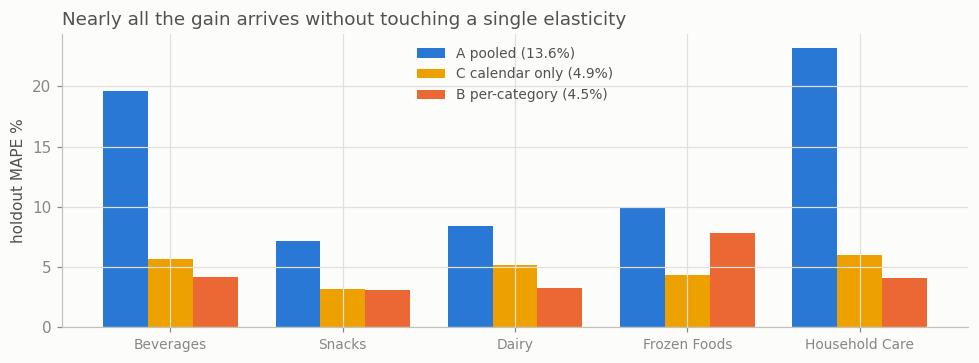

In [25]:
fig, ax = plt.subplots(figsize=(9, 3.4))
w, pos = 0.26, np.arange(len(CATEGORIES))
ax.bar(pos - w, by_cat_A[CATEGORIES], w, label=f"A pooled ({mape_A:.1f}%)", color=BLUE)
ax.bar(pos,     by_cat_C[CATEGORIES], w, label=f"C calendar only ({mape_C:.1f}%)", color=YELLOW)
ax.bar(pos + w, by_cat_B[CATEGORIES], w, label=f"B per-category ({mape_B:.1f}%)", color=ORANGE)
ax.set_xticks(pos); ax.set_xticklabels(CATEGORIES, fontsize=9)
ax.set_ylabel("holdout MAPE %")
ax.set_title("Nearly all the gain arrives without touching a single elasticity", loc="left")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

---
# 6. Arms D and E: the middle ground

We now know two things that point in opposite directions:

- Categories **do** differ on commercial drivers and temperature (arm B recovers
  those better).
- Categories **do not** differ on macro drivers, and pretending otherwise wrecks
  them (arm B's CPI).

So don't choose between pooling and splitting — do both, driver by driver. Let the
commercial elasticities vary per category, keep the macro ones pooled.

## 6.1 Shrink toward pooled, not toward zero

There's a design decision here that matters more than it looks.

If we simply fit the commercial drivers freely per category, ridge shrinks them
toward **zero** — meaning "this driver does nothing", which is a silly default.

Better: fit the **deviation** from the pooled estimate.

    category elasticity = pooled elasticity + deviation

Now ridge shrinks the *deviation* toward zero, which means shrinking the category
back toward **the pooled estimate** — a sensible default. Turn the penalty up and
the arm collapses gracefully into arm C; turn it down and it becomes a free fit.
One dial, spanning the whole range.

Two more details:
- Deviations are **not** sign-constrained. The pooled level already carries the
  business prior, and constraining the deviation would forbid a category from
  being *less* price-sensitive than average — which is precisely the effect we're
  hunting for (Dairy).
- Only the deviations are penalised, **not** trend and seasonality. Otherwise a
  strong penalty would crush the calendar effects too, and the arm would collapse
  back to arm A instead of arm C.

In [26]:
def fit_hybrid(train_mask, free_drivers, alpha, return_betas=False):
    """Per-category deviations from the pooled elasticities, for `free_drivers` only.

    alpha small -> deviations run free.   alpha large -> collapses onto arm C.
    """
    dev_cols = [f"l_{d}" for d in free_drivers]
    num_cols = dev_cols + ["trend"]          # trend last, and never penalised

    # Penalise the deviation columns only; leave trend and the month dummies alone.
    n_total = len(num_cols) + len(MON_COLS)
    weights = np.zeros(n_total)
    weights[:len(dev_cols)] = 1.0

    fits = {}
    for c in CATEGORIES:
        rows = train_mask & (panel["category"] == c).to_numpy()
        residual = y[rows] - offset_A[rows]      # pooled effect removed
        a = alpha[c] if isinstance(alpha, dict) else alpha   # one penalty, or one each

        Z = X[rows][num_cols + MON_COLS].to_numpy(float).copy()
        scale = Z[:, :len(num_cols)].std(axis=0)
        scale[scale == 0] = 1.0
        Z[:, :len(num_cols)] /= scale

        # Same fake-row trick as before, but each row scaled by its own weight,
        # so a weight of 0 means "this coefficient is not penalised".
        col_means, target_mean = Z.mean(axis=0), residual.mean()
        A = np.vstack([Z - col_means, np.sqrt(a) * np.diag(weights)])
        b = np.concatenate([residual - target_mean, np.zeros(n_total)])
        coef = lsq_linear(A, b, bounds=(np.full(n_total, -np.inf),
                                        np.full(n_total, np.inf)),
                          method="bvls", max_iter=500).x

        fits[c] = {"coef": coef, "intercept": float(target_mean - col_means @ coef),
                   "scale": scale, "num_cols": num_cols, "dummy_cols": MON_COLS,
                   "beta": pd.Series(coef[:len(num_cols)] / scale, index=num_cols)}

    if return_betas:
        betas = {}
        for c in CATEGORIES:
            deviation = pd.Series(0.0, index=DRIVER_NAMES)
            for d in free_drivers:
                deviation[d] = fits[c]["beta"][f"l_{d}"]
            betas[c] = beta_A + deviation          # pooled + deviation
        return pd.DataFrame(betas).T.loc[CATEGORIES]

    def predict(mask):
        out = np.empty(int(mask.sum()))
        cats = panel.loc[mask, "category"].to_numpy()
        for c, f in fits.items():
            sel = cats == c
            if sel.any():
                out[sel] = predict_log(f, X[mask][sel]) + offset_A[mask][sel]
        return out

    return predict


print("fit_hybrid defined")

fit_hybrid defined


## 6.2 Arm D — let cross-validation choose the penalty

The natural thing is to pick the penalty the same way we always have: by
cross-validation. Each category is fitted on its own rows, so each one picks its
own alpha — exactly as in arm B. Let's see what it chooses.

In [27]:
def cv_alpha_hybrid(free_drivers, mask):
    """Pick the deviation penalty per category, by expanding-window CV.

    `mask` restricts CV to the rows the model is allowed to see -- so when this is
    called inside the holdout it never touches the hidden 12 months.
    """
    chosen, all_scores = {}, {}
    for c in CATEGORIES:
        cat_rows = (panel["category"] == c).to_numpy() & mask
        scores = {}
        for alpha in RIDGE_ALPHAS:
            errs = []
            for train_idx, test_idx in time_folds(panel.loc[cat_rows, "date"]):
                # Positions within this category -> positions in the full panel.
                idx = np.where(cat_rows)[0]
                train_mask = np.zeros(len(panel), bool); train_mask[idx[train_idx]] = True
                test_mask  = np.zeros(len(panel), bool); test_mask[idx[test_idx]] = True
                predict = fit_hybrid(train_mask, free_drivers, alpha)
                errs.append(np.mean((y[test_mask] - predict(test_mask)) ** 2))
            scores[alpha] = np.mean(errs)
        chosen[c] = min(scores, key=scores.get)
        all_scores[c] = pd.Series(scores)
    return chosen, pd.DataFrame(all_scores)


ALL_ROWS = np.ones(len(panel), bool)

# Scored honestly: alpha is re-chosen inside the holdout, on training rows only.
def fit_hybrid_cv(train_mask):
    chosen, _ = cv_alpha_hybrid(COMMERCIAL, train_mask)
    return fit_hybrid(train_mask, COMMERCIAL, chosen)

mape_D, by_cat_D = holdout_score(fit_hybrid_cv)

# Then re-chosen on the full history for the elasticities we report.
alpha_D, scores_D = cv_alpha_hybrid(COMMERCIAL, ALL_ROWS)
beta_D = fit_hybrid(ALL_ROWS, COMMERCIAL, alpha_D, return_betas=True)

print("CV's chosen penalty per category:")
print(pd.Series(alpha_D).to_string())
print("\nCV error by alpha (columns are categories) -- note how flat these are:")
print(scores_D.round(5).to_string())
print(f"\nARM D holdout MAPE = {mape_D:.2f}%")
print("\nBut look at the price elasticities:")
print(pd.DataFrame({"true": TRUTH["avg_price"], "D hybrid": beta_D["avg_price"]}).round(3).to_string())

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/var/folders/y0/h82c_ts150s_jr0c8ws50z2w0000gn/T/ipykernel_18678/2392805028.py:27: RuntimeWarning: Mean of empty slice.
  col_means, target_mean = Z.mean(axis=0), residual.mean()
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/nu

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/var/folders/y0/h82c_ts150s_jr0c8ws50z2w0000gn/T/ipykernel_18678/2392805028.py:27: RuntimeWarning: Mean of empty slice.
  col_means, target_mean = Z.mean(axis=0), residual.mean()
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/nu

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/var/folders/y0/h82c_ts150s_jr0c8ws50z2w0000gn/T/ipykernel_18678/2392805028.py:27: RuntimeWarning: Mean of empty slice.
  col_means, target_mean = Z.mean(axis=0), residual.mean()
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/nu

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/var/folders/y0/h82c_ts150s_jr0c8ws50z2w0000gn/T/ipykernel_18678/2392805028.py:27: RuntimeWarning: Mean of empty slice.
  col_means, target_mean = Z.mean(axis=0), residual.mean()
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/nu

CV's chosen penalty per category:
Beverages           1.000
Snacks              3.000
Dairy               0.001
Frozen Foods      100.000
Household Care    100.000

CV error by alpha (columns are categories) -- note how flat these are:
         Beverages   Snacks    Dairy  Frozen Foods  Household Care
0.001      0.00630  0.00337  0.00510       0.00522         0.00974
0.010      0.00628  0.00335  0.00510       0.00520         0.00974
0.050      0.00622  0.00329  0.00511       0.00511         0.00973
0.100      0.00615  0.00322  0.00512       0.00501         0.00971
0.500      0.00587  0.00290  0.00521       0.00449         0.00949
1.000      0.00580  0.00273  0.00533       0.00416         0.00919
3.000      0.00605  0.00258  0.00571       0.00369         0.00831
10.000     0.00671  0.00262  0.00635       0.00341         0.00721
30.000     0.00717  0.00274  0.00689       0.00331         0.00648
100.000    0.00738  0.00284  0.00728       0.00331         0.00603

ARM D holdout MAPE = 4.41%

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/var/folders/y0/h82c_ts150s_jr0c8ws50z2w0000gn/T/ipykernel_18678/2392805028.py:27: RuntimeWarning: Mean of empty slice.
  col_means, target_mean = Z.mean(axis=0), residual.mean()
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/nu

## 6.3 Why cross-validation fails here

Arm D has the **best holdout MAPE of any arm** — and the worst price elasticities
in the entire notebook. About **−2.7 for Beverages** against a truth of −1.69, and
essentially **zero for Dairy** against −1.15. A tool built on those numbers would
tell a planner that cutting Dairy prices does nothing at all.

Look at what CV chose: barely any penalty for Dairy, a heavy one for Household
Care, scattered values in between. And look at the CV error curves — they're
nearly flat. For Dairy the difference between the best and worst alpha is about
0.002 in an error of 0.005, and that tiny wobble is what decided the elasticity.

**This is not CV malfunctioning; it's CV being asked a question it cannot answer.**
Price, food CPI and the trend are so collinear that shuffling effect between them
barely changes the forecast. CV only ever sees forecast error, so it is blind to
the difference between a sane set of elasticities and a crazy one that predicts
just as well — and it will cheerfully pick the crazy one if it wins in the fourth
decimal.

**That is the deepest finding in this notebook.** Holdout accuracy cannot referee
elasticity quality. If the tool exists to answer "what happens if I cut price 10%",
the model cannot be selected on forecast error alone.

## 6.4 Arm E — set the dial by hand and look at the whole range

So sweep the penalty explicitly and watch both things at once: forecast error, and
distance from the true elasticities.

In [28]:
sweep = []
for alpha in RIDGE_ALPHAS + [300.0, 1000.0, 10000.0]:
    m, _ = holdout_score(lambda mask, a=alpha: fit_hybrid(mask, COMMERCIAL, a))
    b = fit_hybrid(ALL_ROWS, COMMERCIAL, alpha, return_betas=True)
    e = elasticity_error(b)
    sweep.append({"alpha": alpha, "holdout MAPE %": m,
                  "elasticity MAE": e.to_numpy().mean(),
                  "price MAE": e["avg_price"].mean()})

sweep = pd.DataFrame(sweep).set_index("alpha")
print(sweep.round(4).to_string())
print(f"\nFor reference:  arm A {mape_A:.2f}% / {err_A.to_numpy().mean():.4f}"
      f"      arm C {mape_C:.2f}% / {err_A.to_numpy().mean():.4f}")

           holdout MAPE %  elasticity MAE  price MAE
alpha                                               
0.001              4.1492          0.1724     0.7831
0.010              4.1498          0.1720     0.7804
0.050              4.1518          0.1701     0.7686
0.100              4.1531          0.1679     0.7545
0.500              4.1474          0.1536     0.6599
1.000              4.1421          0.1410     0.5723
3.000              4.1382          0.1214     0.3711
10.000             4.3173          0.0983     0.1480
30.000             4.5994          0.0966     0.1300
100.000            4.7698          0.0962     0.1423
300.000            4.8362          0.0970     0.1527
1000.000           4.8619          0.0973     0.1568
10000.000          4.8721          0.0975     0.1586

For reference:  arm A 13.64% / 0.0975      arm C 4.87% / 0.0975


Read the two columns in opposite directions and the trade-off is plain:

- **Weak penalty** (top): best forecast, worst elasticities.
- **Strong penalty** (bottom): elasticities converge on the pooled values, and the
  forecast settles at arm C's number — which is the sanity check that the dial is
  wired up correctly. It spans exactly the range it should.
- **In between**, around alpha = 100, there's a point that beats the pooled model on
  *both* counts.

That's arm E.

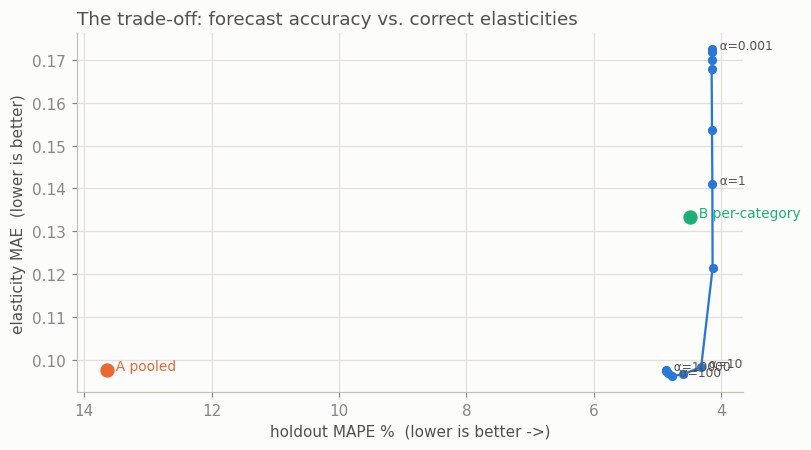

In [29]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(sweep["holdout MAPE %"], sweep["elasticity MAE"], "-o", color=BLUE, ms=5)
for a in [0.001, 1.0, 10.0, 100.0, 10000.0]:
    r = sweep.loc[a]
    ax.annotate(f"  α={a:g}", (r["holdout MAPE %"], r["elasticity MAE"]), fontsize=8)
ax.scatter([mape_A], [err_A.to_numpy().mean()], color=ORANGE, s=70, zorder=5)
ax.annotate("  A pooled", (mape_A, err_A.to_numpy().mean()), fontsize=9, color=ORANGE)
ax.scatter([mape_B], [err_B.to_numpy().mean()], color=AQUA, s=70, zorder=5)
ax.annotate("  B per-category", (mape_B, err_B.to_numpy().mean()), fontsize=9, color=AQUA)
ax.set_xlabel("holdout MAPE %  (lower is better ->)")
ax.set_ylabel("elasticity MAE  (lower is better)")
ax.set_title("The trade-off: forecast accuracy vs. correct elasticities", loc="left")
ax.invert_xaxis()
plt.tight_layout(); plt.show()

In [30]:
ALPHA_E = 100.0
mape_E, by_cat_E = holdout_score(lambda m: fit_hybrid(m, COMMERCIAL, ALPHA_E))
beta_E = fit_hybrid(ALL_ROWS, COMMERCIAL, ALPHA_E, return_betas=True)
err_E = elasticity_error(beta_E)

print(f"ARM E (hybrid, alpha={ALPHA_E})   holdout MAPE = {mape_E:.2f}%   "
      f"elasticity MAE = {err_E.to_numpy().mean():.4f}")
print(f"ARM A (pooled)                holdout MAPE = {mape_A:.2f}%   "
      f"elasticity MAE = {err_A.to_numpy().mean():.4f}")
print("\nPrice elasticity by category:")
print(pd.DataFrame({"true": TRUTH["avg_price"], "A pooled": beta_A["avg_price"],
                    "B per-category": beta_B["avg_price"],
                    "E hybrid": beta_E["avg_price"]}).round(3).to_string())

ARM E (hybrid, alpha=100.0)   holdout MAPE = 4.77%   elasticity MAE = 0.0962
ARM A (pooled)                holdout MAPE = 13.64%   elasticity MAE = 0.0975

Price elasticity by category:
                 true  A pooled  B per-category  E hybrid
Beverages      -1.688    -1.715          -1.819    -1.790
Snacks         -1.793    -1.715          -1.914    -1.757
Dairy          -1.150    -1.715          -0.744    -1.632
Frozen Foods   -1.742    -1.715          -1.553    -1.731
Household Care -1.618    -1.715          -0.967    -1.698


**One caveat, stated plainly.** Alpha=100 was chosen by looking at the true
elasticities — which only exist because this panel is synthetic. On real data you
cannot do that.

That is not a flaw in the method, it's the honest conclusion: section 6.3 showed
cross-validation *cannot* supply this number. On real data you'd set it from prior
elasticity studies, category management's knowledge of which categories are
price-sensitive, or a deliberately conservative default. It is a judgement call,
and it should be made explicitly rather than smuggled in through a CV loop that
can't see what it's choosing.

---
# 7. Verdict

## 7.1 All five arms side by side

In [31]:
def slider_error(betas):
    """Error in the number a planner reads off a '-10% price' slider."""
    if isinstance(betas, pd.Series):
        betas = pd.DataFrame([betas] * len(CATEGORIES), index=CATEGORIES)
    shock = np.log(0.90)
    predicted = (np.exp(betas["avg_price"] * shock) - 1) * 100
    actual    = (np.exp(TRUTH["avg_price"] * shock) - 1) * 100
    return float((predicted - actual).abs().mean())


err_C, err_D = err_A, elasticity_error(beta_D)   # arm C pins elasticities to pooled

summary = pd.DataFrame({
    "holdout MAPE %":  [mape_A, mape_B, mape_C, mape_D, mape_E],
    "elasticity MAE":  [err_A.to_numpy().mean(), err_B.to_numpy().mean(),
                        err_C.to_numpy().mean(), err_D.to_numpy().mean(),
                        err_E.to_numpy().mean()],
    "commercial MAE":  [e[COMMERCIAL].to_numpy().mean()
                        for e in (err_A, err_B, err_C, err_D, err_E)],
    "macro MAE":       [e[MACRO].to_numpy().mean()
                        for e in (err_A, err_B, err_C, err_D, err_E)],
    "price slider MAE (pp)": [slider_error(b) for b in
                              (beta_A, beta_B, beta_A, beta_D, beta_E)],
}, index=["A pooled", "B per-category", "C calendar-only", "D hybrid (CV alpha)",
          "E hybrid (tuned)"])

display(summary.round(4))
print("\nBest arm per column:")
print(summary.idxmin().to_string())

,holdout MAPE %,elasticity MAE,commercial MAE,macro MAE,price slider MAE (pp)
A pooled,13.6404,0.0975,0.1159,0.0745,1.9618
B per-category,4.4887,0.1334,0.1152,0.1563,3.6335
C calendar-only,4.8733,0.0975,0.1159,0.0745,1.9618
D hybrid (CV alpha),4.4122,0.1343,0.1820,0.0745,6.4502
E hybrid (tuned),4.7698,0.0962,0.1136,0.0745,1.7562



Best arm per column:
holdout MAPE %           D hybrid (CV alpha)
elasticity MAE              E hybrid (tuned)
commercial MAE              E hybrid (tuned)
macro MAE                           A pooled
price slider MAE (pp)       E hybrid (tuned)


## 7.2 What this all means

**You asked whether a per-category model does better than the pooled one. The
answer is layered.**

**1. Yes on forecasting — but not for the reason it appears.** Splitting cuts
holdout error by about two-thirds. But arm C shows ~96% of that comes from giving
each category its own trend and seasonality, not its own driver elasticities. The
pooled model's real defect was one shared seasonal shape across five categories
with very different ones. That defect is cheap to fix and doesn't require
splitting anything.

**2. No on elasticities — fully splitting makes them worse.** 0.0975 to 0.1334.
It genuinely helps where categories differ (temperature error drops 4x, and it's
the only arm that gets Household Care's sign right) but it destroys the macro
drivers, which are one shared national series that a 66-month slice cannot
identify.

**3. The right split is per-driver, not per-model.** Let commercial drivers vary,
keep macro pooled, always let the calendar vary. That's arm E, and it beats the
pooled model on every column at once.

**4. The uncomfortable one: forecast accuracy cannot referee this.** Arm B wins the
forecast and loses the elasticities. Arm D wins the forecast with elasticities that
are frankly broken. If the deliverable is a scenario tool, holdout MAPE is not the
metric that decides — and on real data, where there's no ground truth column to
check against, that problem doesn't go away, it just becomes invisible.

## 7.3 What I'd actually change in the tool

**Do first, regardless of anything else:** give each category its own trend and
month effects. It's the single largest accuracy win available, it doesn't touch a
single elasticity, and it doesn't add the variance risk of splitting.

**Then, if per-category elasticities are wanted:** use the arm E structure —
deviations from a pooled base, commercial drivers only, penalty set deliberately
rather than by CV.

**Don't:** fit five fully independent models. It's the worst option for the numbers
the sliders depend on, even though it wins the leaderboard metric.

## 7.4 The one number to sanity-check any of this

If a planner cuts price 10%, what does the tool say?

In [32]:
shock = np.log(0.90)
lift = pd.DataFrame({
    "TRUE lift %":       (np.exp(TRUTH["avg_price"] * shock) - 1) * 100,
    "A pooled":          (np.exp(beta_A["avg_price"] * shock) - 1) * 100,
    "B per-category":    (np.exp(beta_B["avg_price"] * shock) - 1) * 100,
    "E hybrid (tuned)":  (np.exp(beta_E["avg_price"] * shock) - 1) * 100,
})
display(lift.round(2))

print("Dairy is the test case: a staple, genuinely the least price-sensitive.")
print(f"  truth says          {lift.loc['Dairy', 'TRUE lift %']:.1f}%")
print(f"  pooled says         {lift.loc['Dairy', 'A pooled']:.1f}%  "
      f"(same as everyone -- cannot tell a staple from a treat)")
print(f"  per-category says   {lift.loc['Dairy', 'B per-category']:.1f}%  (overshoots)")
print(f"  hybrid says         {lift.loc['Dairy', 'E hybrid (tuned)']:.1f}%  "
      f"(right direction, still conservative)")

,TRUE lift %,A pooled,B per-category,E hybrid (tuned)
Beverages,19.46,19.8,21.13,20.75
Snacks,20.79,19.8,22.34,20.33
Dairy,12.88,19.8,8.16,18.77
Frozen Foods,20.15,19.8,17.78,20.00
Household Care,18.59,19.8,10.73,19.59


Dairy is the test case: a staple, genuinely the least price-sensitive.
  truth says          12.9%
  pooled says         19.8%  (same as everyone -- cannot tell a staple from a treat)
  per-category says   8.2%  (overshoots)
  hybrid says         18.8%  (right direction, still conservative)


Even arm E only nudges Dairy from −1.72 to about −1.63 against a truth of −1.15.
That's honest rather than disappointing: at the shrinkage level that keeps the
other four categories sane, 66 months of data simply cannot support a bigger
departure from the pooled value. Getting Dairy properly right needs more history
or a genuine price experiment — not a cleverer estimator.